In [1]:
import datasets
ds = datasets.Dataset.from_json('../downloaded_eval_results')
ds

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores'],
    num_rows: 50
})

In [2]:
def map_fn(example):
    example["is_correct"] = [x == 1.0 for x in example["scores"]]
    return example

ds = ds.map(map_fn)
ds

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores', 'is_correct'],
    num_rows: 50
})

In [3]:
import numpy as np
from scipy.special import comb
from tqdm import tqdm

def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [4]:
def calculate_pass_at_k_corrected(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    pass_at_k_values = []
    
    for k in range(1, n_samples + 1):
        pass_at_k_per_problem = []
        
        for problem_idx in range(n_problems):
            correct_samples = np.sum(correctness_matrix[problem_idx])
            
            pass_k = pass_at_k(n_samples, correct_samples, k)
            pass_at_k_per_problem.append(pass_k)
        
        avg_pass_at_k = np.mean(pass_at_k_per_problem)
        pass_at_k_values.append(avg_pass_at_k)
    
    return np.array(pass_at_k_values)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

correctness_matrix = np.array(ds["is_correct"])
pass_at_k_values = np.asarray(calculate_pass_at_k_corrected(correctness_matrix))

print(pass_at_k_values)

[0.28875    0.4565     0.55878571 0.62437363 0.66849817 0.69953047
 0.72226573 0.73954934 0.75311189 0.76402597 0.77297161 0.7803956
 0.78660714 0.79183333 0.79625    0.8       ]


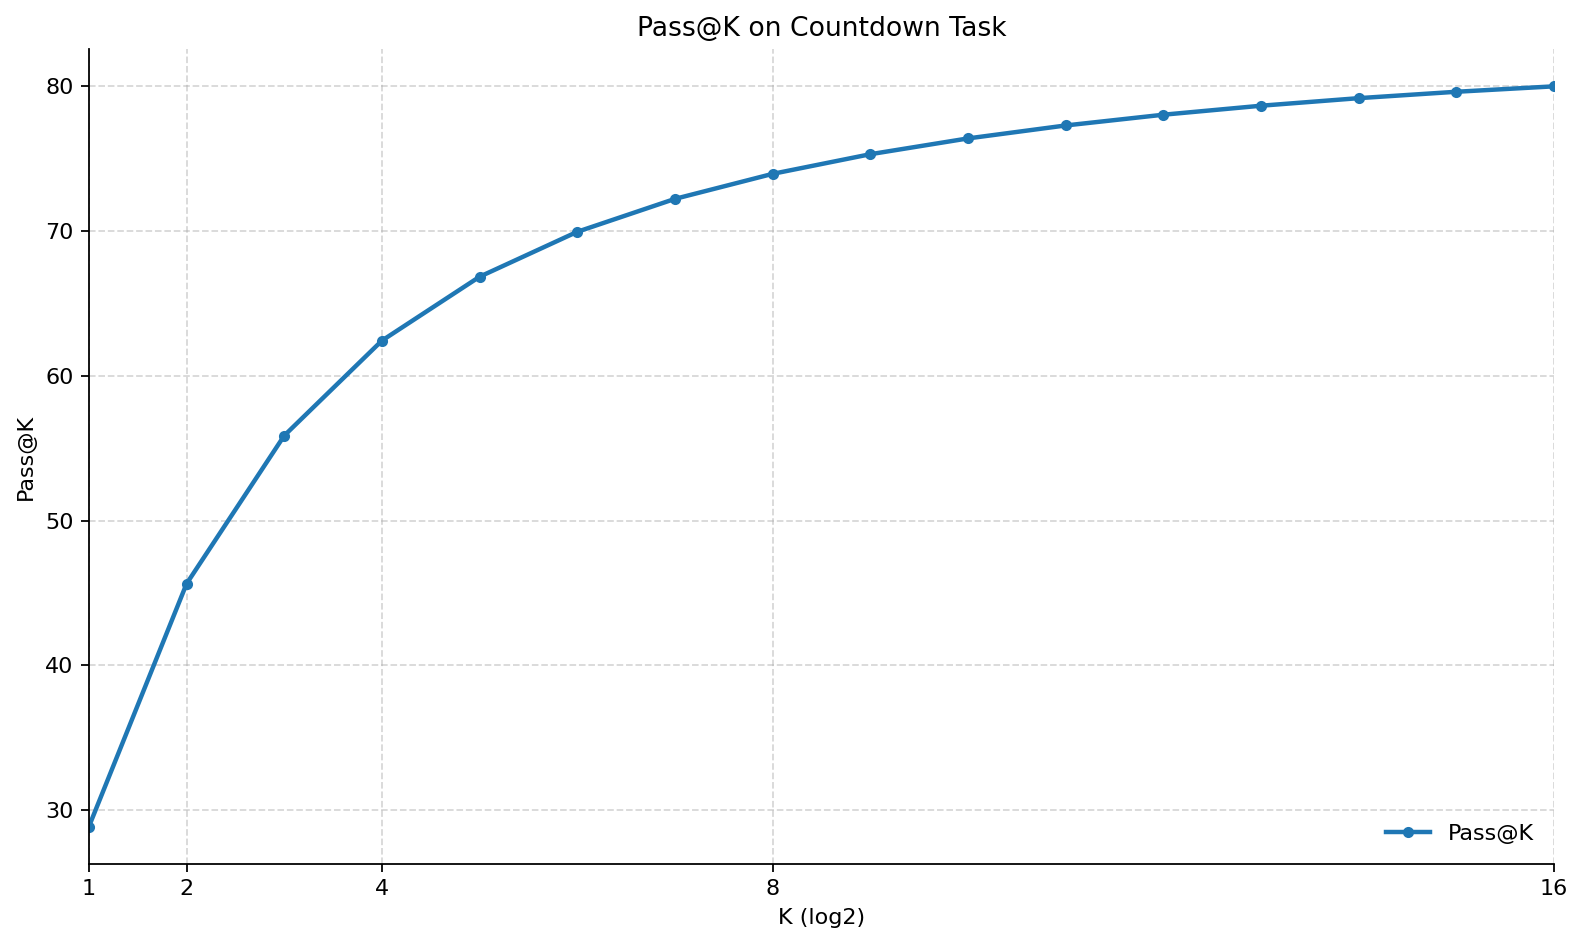

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

k = np.arange(1, len(pass_at_k_values) + 1)

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=160)

ax.plot(k, pass_at_k_values * 100, marker="o", markersize=4, linewidth=2, label="Pass@K")

ax.set_xlabel("K (log2)")
ax.set_ylabel("Pass@K")
ax.set_title("Pass@K on Countdown Task")
ax.set_xlim(1, k[-1])

major_ticks = [t for t in [1, 2, 4, 8, 16] if t <= k[-1]]
ax.xaxis.set_major_locator(FixedLocator(major_ticks))
ax.set_xticklabels([str(t) for t in major_ticks])

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()